# Dataset pipeline (small run)

This notebook builds a small dataset example.
It uses a notebook-only config so it does not mix with bigger runs.


## Setup


In [8]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import yaml

from skin_diffusion.notebook_helpers import setup_repo_root, run_module, assert_paths_exist

repo_root = setup_repo_root()
print('repo_root:', repo_root)


repo_root: C:\Users\nwals\Documents\COMP3931_IndividualProject


## Make a notebook-only config

Copies V3 config and changes output folder + seed.


In [9]:
base_cfg = Path('configs/sim/v3_hetero_patch_timeDecay.yaml')
nb_cfg = Path('configs/sim/v3_notebook_dataset.yaml')

raw = yaml.safe_load(base_cfg.read_text(encoding='utf-8'))
raw['output_dir'] = 'outputs/sim/v3_notebook'
raw['seed'] = 777

nb_cfg.write_text(yaml.safe_dump(raw, sort_keys=False), encoding='utf-8')
print('wrote', nb_cfg)


wrote configs\sim\v3_notebook_dataset.yaml


## Generate and assemble

Runs:
1. dataset generation,
2. train/val assembly.


In [10]:
# generate runs
run_module(
    'scripts.sim.make_dataset',
    ['--config', str(nb_cfg), '--num_runs', '3', '--seed_start', '777'],
    repo_root=repo_root,
)

# assemble processed splits
run_module(
    'scripts.sim.assemble_dataset',
    [
        '--config', str(nb_cfg),
        '--out_dir', 'data/processed/v3_notebook',
        '--split_seed', '321',
        '--train_frac', '0.67',
        '--val_frac', '0.33',
    ],
    repo_root=repo_root,
)

assert_paths_exist([
    'data/processed/v3_notebook/v3_train.npz',
    'data/processed/v3_notebook/v3_val.npz',
    'data/processed/v3_notebook/index.json',
])
print('saved in data/processed/v3_notebook')


running: c:\Users\nwals\Documents\COMP3931_IndividualProject\.venv\Scripts\python.exe -m scripts.sim.make_dataset --config configs\sim\v3_notebook_dataset.yaml --num_runs 3 --seed_start 777
running: c:\Users\nwals\Documents\COMP3931_IndividualProject\.venv\Scripts\python.exe -m scripts.sim.assemble_dataset --config configs\sim\v3_notebook_dataset.yaml --out_dir data/processed/v3_notebook --split_seed 321 --train_frac 0.67 --val_frac 0.33
saved in data/processed/v3_notebook


## Check shapes

Confirms files and array shapes are as expected.


In [11]:
train = np.load('data/processed/v3_notebook/v3_train.npz')
val = np.load('data/processed/v3_notebook/v3_val.npz')
index = json.loads(Path('data/processed/v3_notebook/index.json').read_text(encoding='utf-8'))

print('train keys:', sorted(train.files))
print('val keys:', sorted(val.files))
print('train C_snap:', train['C_snap'].shape)
print('val C_snap:', val['C_snap'].shape)
print('index rows:', len(index['index']))


train keys: ['C_snap', 'D', 'J', 'k', 'patch_mask', 't']
val keys: ['C_snap', 'D', 'J', 'k', 'patch_mask', 't']
train C_snap: (2, 20001, 64, 64)
val C_snap: (1, 20001, 64, 64)
index rows: 3


## Example figures

Top row:
- sample heatmaps at start/mid/end.

Bottom row:
- sample depth profiles,
- flux curves for all train samples.


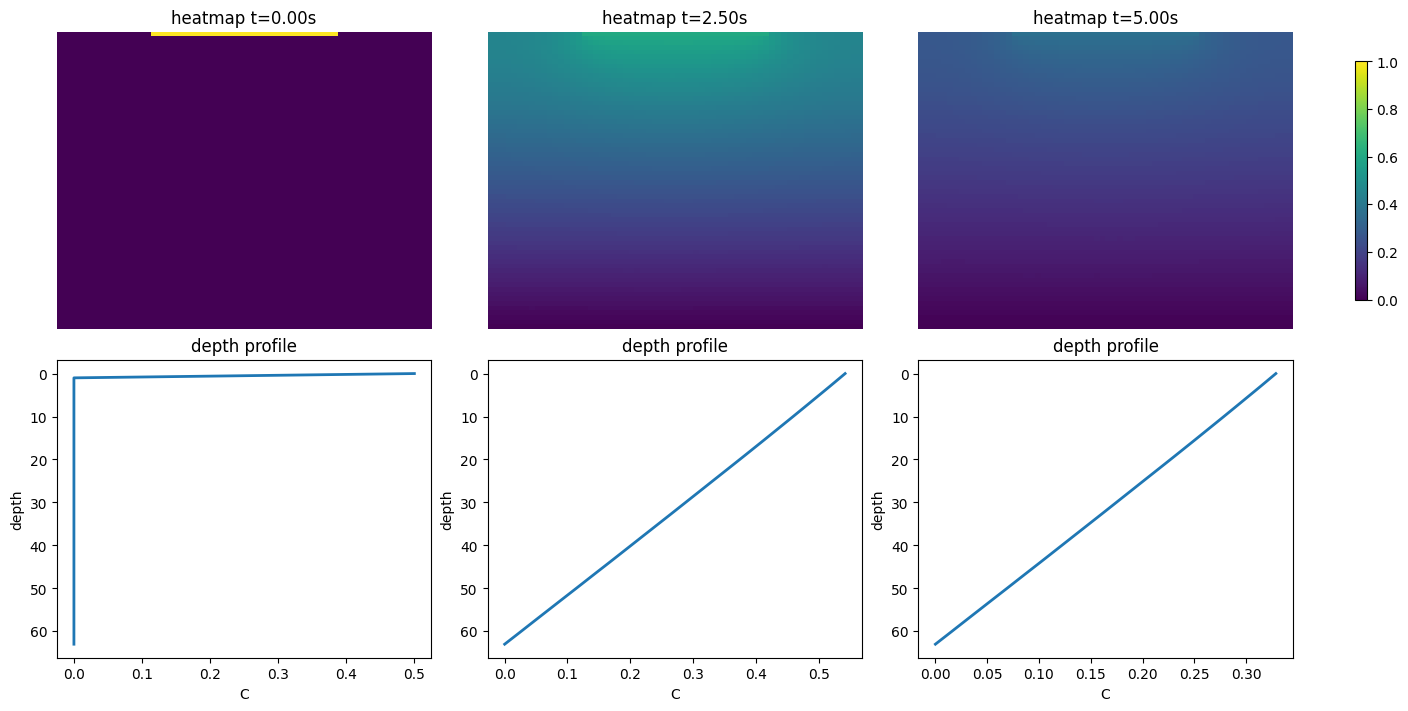

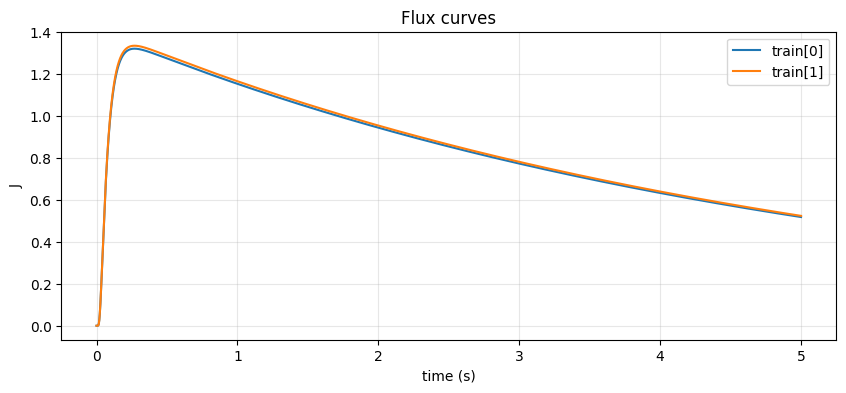

In [12]:
sample = train['C_snap'][0]
sample_t = train['t'][0]
idxs = [0, len(sample_t) // 2, len(sample_t) - 1]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
vmax = float(sample.max())

for col in range(3):
    idx = idxs[col]

    # sample heatmap
    im = axes[0, col].imshow(sample[idx], origin='upper', aspect='auto', vmin=0.0, vmax=vmax)
    axes[0, col].set_title(f'heatmap t={sample_t[idx]:.2f}s')
    axes[0, col].axis('off')

    # sample depth profile
    profile = sample[idx].mean(axis=1)
    axes[1, col].plot(profile, np.arange(profile.size), lw=2)
    axes[1, col].invert_yaxis()
    axes[1, col].set_title('depth profile')
    axes[1, col].set_xlabel('C')
    axes[1, col].set_ylabel('depth')

fig.colorbar(im, ax=axes[0, :], shrink=0.8)
plt.show()

# plot train flux curves
plt.figure(figsize=(10, 4))
for i in range(train['J'].shape[0]):
    plt.plot(train['t'][i], train['J'][i], lw=1.5, label=f'train[{i}]')

plt.title('Flux curves')
plt.xlabel('time (s)')
plt.ylabel('J')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
